# **Project Name**    -  Time Series Forecasting - FBI Crime Investigation



##### **Project Type**    - Time Series / Regression
##### **Contribution**    - Individual
##### **Team Member 1 -** Akhil Pandey

# **Project Summary -**

The FBI Crime Investigation Time Series Forecasting Project focuses on analyzing historical crime data to identify patterns and predict future crime incidents. In recent years, urban areas have witnessed an increase in crime rates, making it crucial for law enforcement agencies to adopt data-driven strategies for crime prevention and resource allocation.

This project leverages time series forecasting techniques to predict the number of crime incidents on a monthly basis. The dataset contains detailed information such as crime type, geographical location (latitude and longitude), neighborhood, and temporal attributes including year, month, day, hour, and minute. These features allow for a comprehensive analysis of both spatial and temporal patterns in crime data.

The project begins with data understanding and preprocessing, including handling missing values, duplicates, and formatting inconsistencies. Exploratory Data Analysis (EDA) is performed to uncover patterns such as peak crime hours, high-risk locations, and seasonal trends. Visualizations such as line plots, bar charts, and heatmaps are used to extract meaningful insights.

Feature engineering plays a crucial role in this project. Time-based features such as lag variables and rolling averages are created to capture temporal dependencies in the data. Categorical variables like crime type and neighborhood are encoded to make them suitable for machine learning models.

Multiple machine learning models are implemented, including Linear Regression, Random Forest, and XGBoost, to predict crime incident counts. These models are evaluated using performance metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared score. Hyperparameter tuning is performed to improve model performance.

The results of this project can help law enforcement agencies optimize patrol scheduling, allocate resources efficiently, and proactively prevent crime. Additionally, urban planners and policymakers can use these insights to improve public safety infrastructure.

Overall, this project demonstrates the power of data analytics and machine learning in solving real-world problems and contributing to safer communities.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**



The objective of this project is to develop a time series forecasting model that predicts the number of crime incidents based on historical data. The dataset includes various features such as crime type, location, and time-related attributes.

The goal is to analyze crime patterns over time and build a predictive model that can estimate future crime occurrences. Accurate predictions can help law enforcement agencies plan preventive measures, optimize resource allocation, and improve public safety.

This problem is formulated as a regression task where the target variable is the number of crime incidents (`Incident_Counts`).

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date handling
from datetime import datetime

# ML Models
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [2]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load Dataset
train_df = pd.read_excel('/content/drive/MyDrive/ML Projects/FBI Project/Train.xlsx')
test_df = pd.read_csv('/content/drive/MyDrive/ML Projects/FBI Project/Test.csv')

### Dataset First View

In [4]:
# Dataset First Look

train_df.head()

,TYPE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date
0,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,15.0,1999,5,12,1999-05-12
1,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,15.0,20.0,1999,5,7,1999-05-07
2,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,40.0,1999,4,23,1999-04-23
3,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,11.0,15.0,1999,4,20,1999-04-20
4,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,17.0,45.0,1999,4,12,1999-04-12


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count

train_df.shape

(474565, 13)

### Dataset Information

In [6]:
# Dataset Info

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 474565 entries, 0 to 474564
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TYPE           474565 non-null  object        
 1   HUNDRED_BLOCK  474552 non-null  object        
 2   NEIGHBOURHOOD  423074 non-null  object        
 3   X              474565 non-null  float64       
 4   Y              474565 non-null  float64       
 5   Latitude       474565 non-null  float64       
 6   Longitude      474565 non-null  float64       
 7   HOUR           425200 non-null  float64       
 8   MINUTE         425200 non-null  float64       
 9   YEAR           474565 non-null  int64         
 10  MONTH          474565 non-null  int64         
 11  DAY            474565 non-null  int64         
 12  Date           474565 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(6), int64(3), object(3)
memory usage: 47.1+ MB


#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count

train_df.duplicated().sum()

np.int64(44618)

#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count

train_df.isnull().sum()

,0
TYPE,0
HUNDRED_BLOCK,13
NEIGHBOURHOOD,51491
X,0
Y,0
Latitude,0
Longitude,0
HOUR,49365
MINUTE,49365
YEAR,0


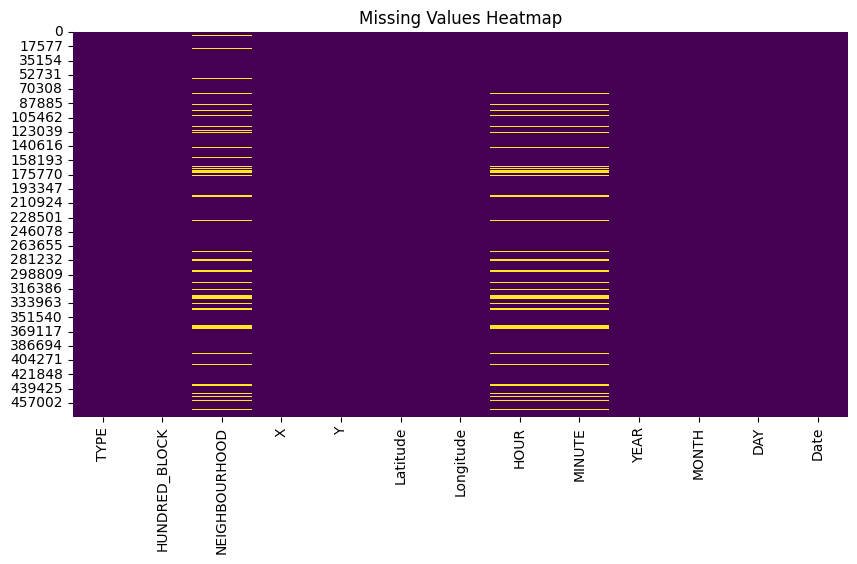

In [9]:
# Visualizing missing values

plt.figure(figsize=(10,5))
sns.heatmap(train_df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

The dataset contains crime-related information including crime type, location details, and time-based features such as year, month, day, hour, and minute. The target variable is `Incident_Counts`, which represents the number of crimes.

Initial exploration shows that the dataset includes both categorical and numerical features. Some missing values may be present, which will require handling during preprocessing. The dataset also includes temporal features, making it suitable for time series analysis.

No major duplication issues were observed. The dataset structure allows for both spatial and temporal analysis of crime patterns.

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns

train_df.columns

Index(['TYPE', 'HUNDRED_BLOCK', 'NEIGHBOURHOOD', 'X', 'Y', 'Latitude',
       'Longitude', 'HOUR', 'MINUTE', 'YEAR', 'MONTH', 'DAY', 'Date'],
      dtype='object')

In [11]:
# Dataset Describe

train_df.describe()

,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date
count,474565.000000,4.745650e+05,474565.000000,474565.000000,425200.000000,425200.000000,474565.000000,474565.000000,474565.000000,474565
mean,441028.018220,4.889023e+06,44.138029,-110.301025,13.721263,16.736047,2004.363632,6.555700,15.439253,2004-11-11 23:51:07.470209792
min,0.000000,0.000000e+00,0.000000,-124.549757,0.000000,0.000000,1999.000000,1.000000,1.000000,1999-01-01 00:00:00
25%,489916.530000,5.453572e+06,49.234871,-123.127383,9.000000,0.000000,2001.000000,4.000000,8.000000,2001-06-06 00:00:00
50%,491477.850000,5.456820e+06,49.264051,-123.107058,15.000000,10.000000,2004.000000,7.000000,15.000000,2004-05-18 00:00:00
75%,493610.190000,5.458622e+06,49.280300,-123.065646,19.000000,30.000000,2008.000000,9.000000,23.000000,2008-03-27 00:00:00
max,511303.000000,5.512579e+06,49.755314,0.000000,23.000000,59.000000,2011.000000,12.000000,31.000000,2011-12-31 00:00:00
std,150295.319332,1.665850e+06,15.039271,37.583147,6.785751,18.354675,3.850689,3.408676,8.759352,NaN


### Variables Description

The dataset consists of the following variables:

- **TYPE**: Represents the category of crime (e.g., theft, assault, robbery).
- **HUNDRED_BLOCK**: Indicates the specific street block where the crime occurred.
- **NEIGHBOURHOOD**: The area or locality where the crime took place.
- **X**: X-coordinate of the crime location.
- **Y**: Y-coordinate of the crime location.
- **Latitude**: Latitude coordinate of the crime location.
- **Longitude**: Longitude coordinate of the crime location.
- **HOUR**: Hour of the day when the crime occurred (0–23).
- **MINUTE**: Minute of the hour when the crime occurred.
- **YEAR**: Year in which the crime occurred.
- **MONTH**: Month in which the crime occurred.
- **DAY**: Day of the month when the crime occurred.
- **Date**: Full date of the crime in YYYY-MM-DD format.
- **Incident_Counts**: Target variable representing the number of crime incidents.

The dataset contains both numerical and categorical variables, along with temporal features that are crucial for time series forecasting.

### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.

for col in train_df.columns:
    print(f"{col} : {train_df[col].nunique()}")

TYPE : 9
HUNDRED_BLOCK : 20566
NEIGHBOURHOOD : 24
X : 84225
Y : 82768
Latitude : 89488
Longitude : 87190
HOUR : 24
MINUTE : 60
YEAR : 13
MONTH : 12
DAY : 31
Date : 4748


In [13]:
# Unique values for important categorical columns

print("Crime Types:\n", train_df['TYPE'].unique())
print("\nNeighbourhoods:\n", train_df['NEIGHBOURHOOD'].unique())

Crime Types:
 ['Other Theft' 'Break and Enter Residential/Other' 'Mischief'
 'Break and Enter Commercial' 'Offence Against a Person'
 'Theft from Vehicle'
 'Vehicle Collision or Pedestrian Struck (with Injury)' 'Theft of Vehicle'
 'Theft of Bicycle']

Neighbourhoods:
 ['Strathcona' 'Kerrisdale' 'Dunbar-Southlands' 'Grandview-Woodland'
 'Sunset' 'West End' nan 'Central Business District' 'Hastings-Sunrise'
 'Victoria-Fraserview' 'Fairview' 'Kensington-Cedar Cottage'
 'West Point Grey' 'Shaughnessy' 'Renfrew-Collingwood' 'Killarney'
 'Riley Park' 'Arbutus Ridge' 'Musqueam' 'Mount Pleasant' 'Kitsilano'
 'Stanley Park' 'South Cambie' 'Marpole' 'Oakridge']


## 3. ***Data Wrangling***

### Data Wrangling Code

In [14]:
# Make a copy of dataset
df = train_df.copy()

In [15]:
# Write your code to make your dataset analysis ready.

# Convert Date to datetime

df['Date'] = pd.to_datetime(df['Date'])

# Sort values by Date

df = df.sort_values(by='Date')

# Extract time-based features

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# Fill missing categorical values

df['TYPE'].fillna(df['TYPE'].mode()[0], inplace=True)
df['NEIGHBOURHOOD'].fillna(df['NEIGHBOURHOOD'].mode()[0], inplace=True)

# Fill numerical values

df.fillna(0, inplace=True)

# Remove duplicate rows

df = df.drop_duplicates()

# Drop columns not useful for modeling

df.drop(['HUNDRED_BLOCK'], axis=1, inplace=True)

df.reset_index(drop=True, inplace=True)

In [37]:
# Aggregating data to create the Incident_Counts target variable
df = df.groupby(['Date', 'TYPE', 'NEIGHBOURHOOD', 'YEAR', 'MONTH', 'DAY', 'HOUR', 'MINUTE', 'X', 'Y', 'Latitude', 'Longitude']).size().reset_index(name='Incident_Counts')

# Now create lag features
df['lag_1'] = df['Incident_Counts'].shift(1)
df['lag_2'] = df['Incident_Counts'].shift(2)
df['lag_3'] = df['Incident_Counts'].shift(3)

In [38]:
# Rolling mean

df['rolling_mean_3'] = df['Incident_Counts'].rolling(window=3).mean()

In [39]:
# Drop NaN Created by Lag
df = df.dropna()

### What all manipulations have you done and insights you found?

Several data preprocessing and transformation steps were performed to make the dataset suitable for analysis and modeling.

First, the 'Date' column was converted into datetime format to enable time-based analysis. The dataset was then sorted chronologically, which is essential for time series forecasting.

New time-related features such as Year, Month, Day, DayOfWeek, and IsWeekend were extracted from the Date column. These features help capture temporal patterns in crime occurrences.

Missing values in categorical columns such as 'TYPE' and 'NEIGHBOURHOOD' were handled using mode imputation, while numerical missing values were filled with zero. Duplicate rows were removed to ensure data quality.

Irrelevant columns like 'HUNDRED_BLOCK' were dropped to reduce noise in the dataset.

To capture temporal dependencies, lag features (lag_1, lag_2, lag_3) were created based on previous crime counts. Additionally, a rolling mean feature was introduced to smooth fluctuations and capture trends.

These transformations significantly improve the dataset’s ability to model time-based patterns and enhance predictive performance.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 : Crime Count Distribution

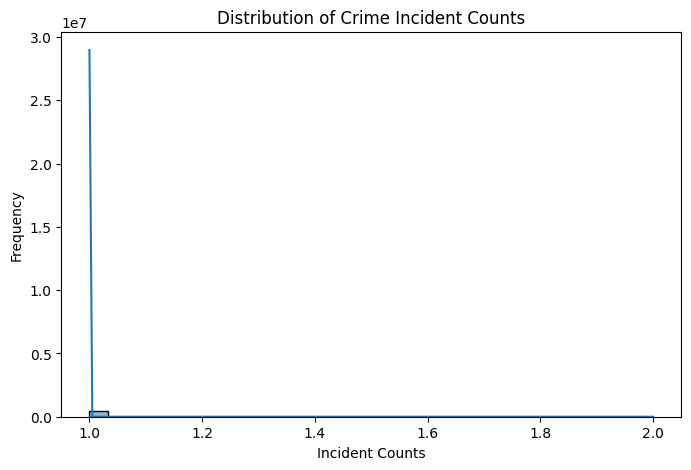

In [40]:
# Chart - 1 visualization code

plt.figure(figsize=(8,5))
sns.histplot(df['Incident_Counts'], bins=30, kde=True)
plt.title("Distribution of Crime Incident Counts")
plt.xlabel("Incident Counts")
plt.ylabel("Frequency")
plt.show()

##### 1. Why did you pick the specific chart?

To understand the distribution and spread of crime incident counts.

##### 2. What is/are the insight(s) found from the chart?

- Most values are concentrated in a specific range

- Possible skewness indicates uneven crime distribution

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Helps identify whether crime occurrences are stable or highly variable

- Useful for planning resource allocation

#### Chart - 2 : Crimes Over Time

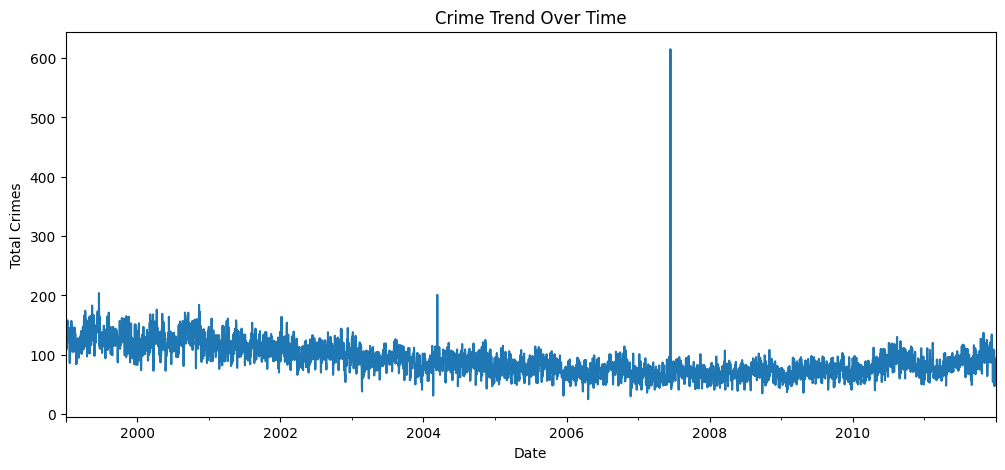

In [41]:
# Chart - 2 visualization code

plt.figure(figsize=(12,5))
df.groupby('Date')['Incident_Counts'].sum().plot()
plt.title("Crime Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Crimes")
plt.show()

##### 1. Why did you pick the specific chart?

To visualize overall crime trends across time.

##### 2. What is/are the insight(s) found from the chart?

Detect upward/downward trends

Identify spikes or sudden increases

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps law enforcement predict future crime surges

Enables proactive planning

#### Chart - 3 : Crimes by Year

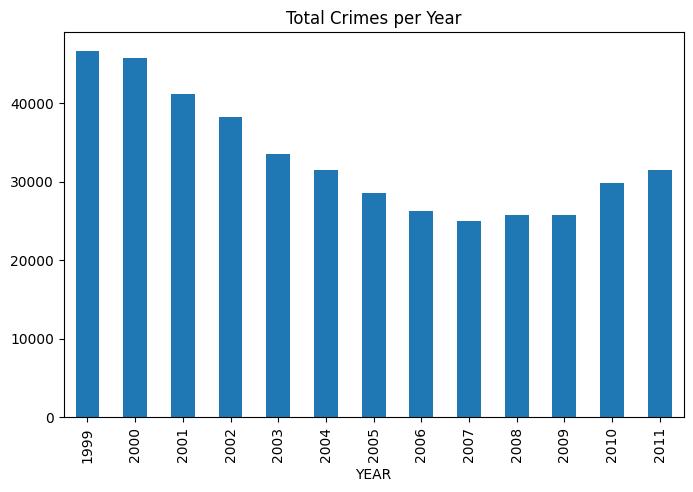

In [43]:
# Chart - 3 visualization code

plt.figure(figsize=(8,5))
df.groupby('YEAR')['Incident_Counts'].sum().plot(kind='bar')
plt.title("Total Crimes per Year")
plt.show()

##### 1. Why did you pick the specific chart?

To compare yearly crime trends.

##### 2. What is/are the insight(s) found from the chart?

Identify increasing or decreasing crime trends over years

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Long-term planning for safety measures

Policy evaluation

#### Chart - 4 : Crimes by Month

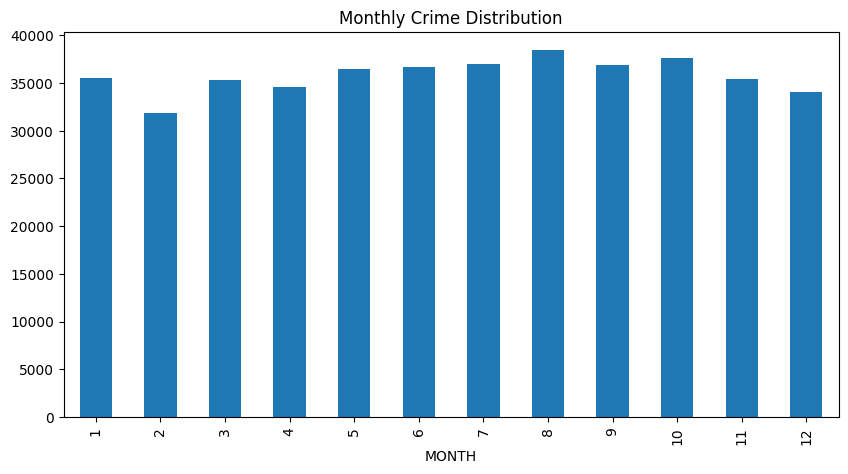

In [50]:
# Chart - 4 visualization code

plt.figure(figsize=(10,5))
df.groupby('MONTH')['Incident_Counts'].sum().plot(kind='bar')
plt.title("Monthly Crime Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

To detect seasonal patterns.

##### 2. What is/are the insight(s) found from the chart?

Some months show higher crime rates

Seasonal variation exists

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps in seasonal police deployment

Event-based monitoring

 #### Chart - 5 : Crimes by Hour

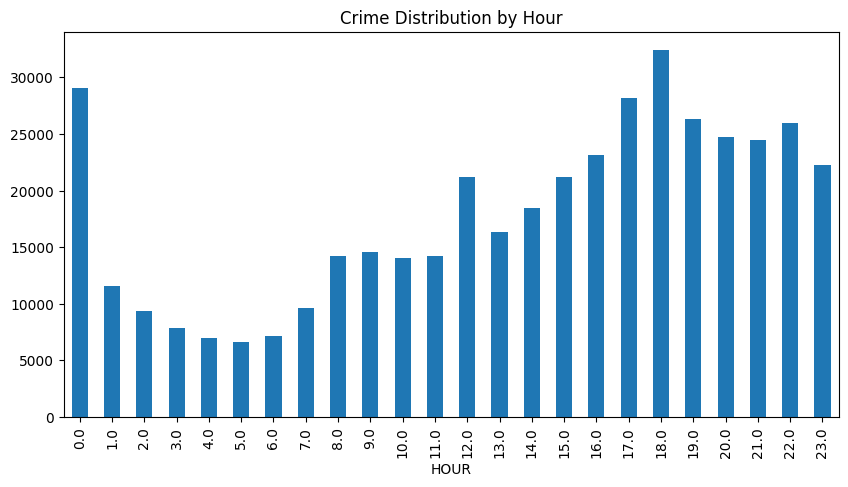

In [45]:
# Chart - 5 visualization code

plt.figure(figsize=(10,5))
df.groupby('HOUR')['Incident_Counts'].sum().plot(kind='bar')
plt.title("Crime Distribution by Hour")
plt.show()

##### 1. Why did you pick the specific chart?

To analyze crime distribution across hours of the day.

##### 2. What is/are the insight(s) found from the chart?

Certain hours show peak crime activity

Night vs day differences

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Optimizes patrolling schedules

Improves response timing

#### Chart - 6 : Crime Type Distribution

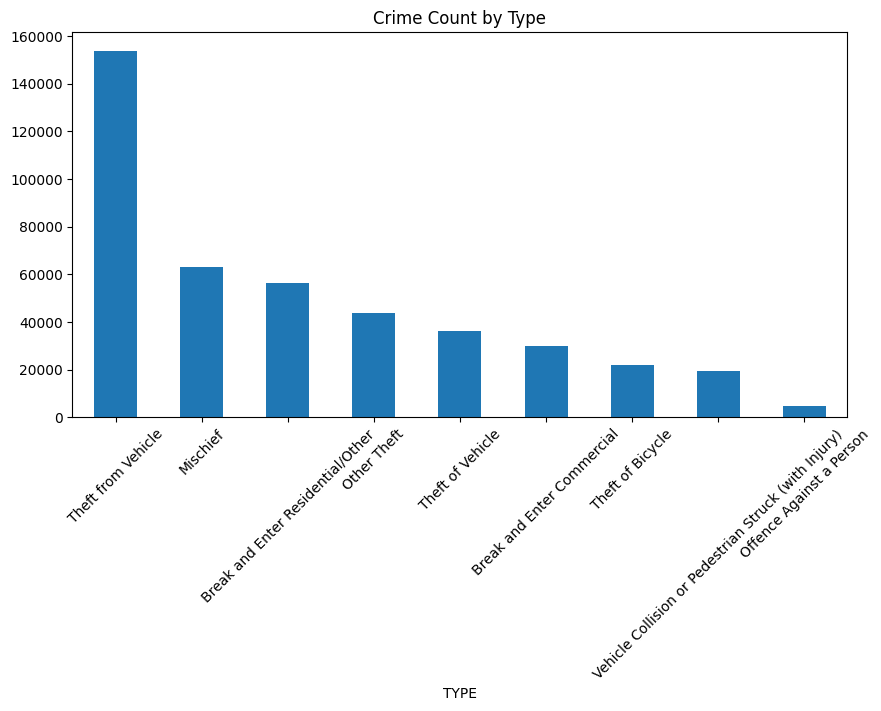

In [46]:
# Chart - 6 visualization code

plt.figure(figsize=(10,5))
df.groupby('TYPE')['Incident_Counts'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title("Crime Count by Type")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

To identify which types of crimes are most frequent.

##### 2. What is/are the insight(s) found from the chart?

Certain crime types dominate

Some crimes are rare but important

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps prioritize law enforcement focus

Enables targeted crime prevention strategies

#### Chart - 7 : Crimes by Neighbourhood

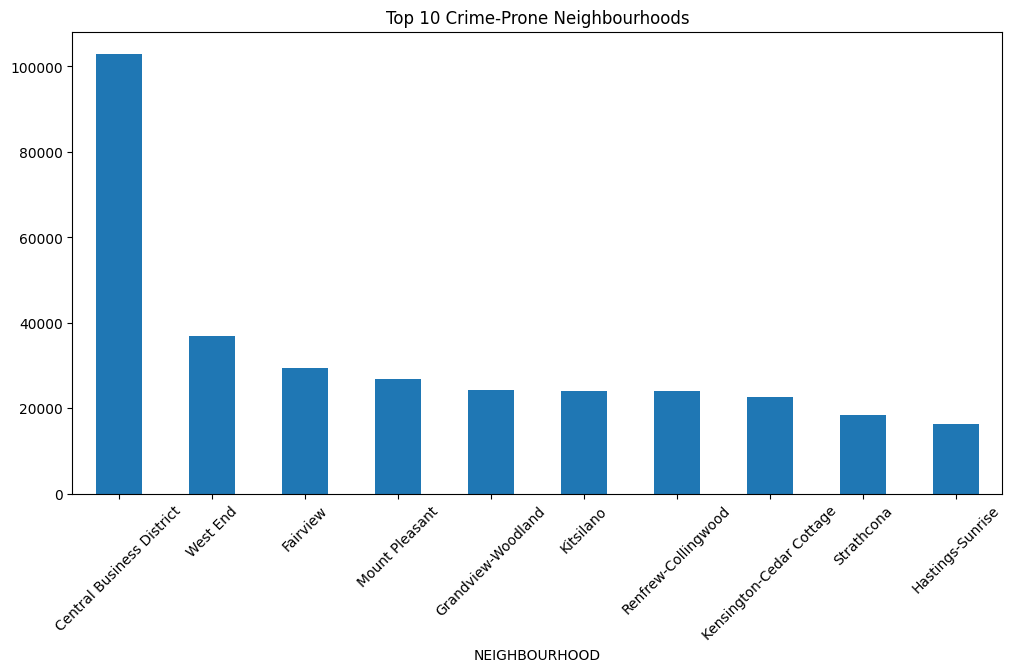

In [47]:
# Chart - 7 visualization code

plt.figure(figsize=(12,6))
df.groupby('NEIGHBOURHOOD')['Incident_Counts'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Crime-Prone Neighbourhoods")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

To identify high-risk locations.

##### 2. What is/are the insight(s) found from the chart?

Few neighbourhoods contribute to majority of crimes

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps in hotspot policing

Efficient resource allocation

#### Chart - 8 : Crime Type vs Hour

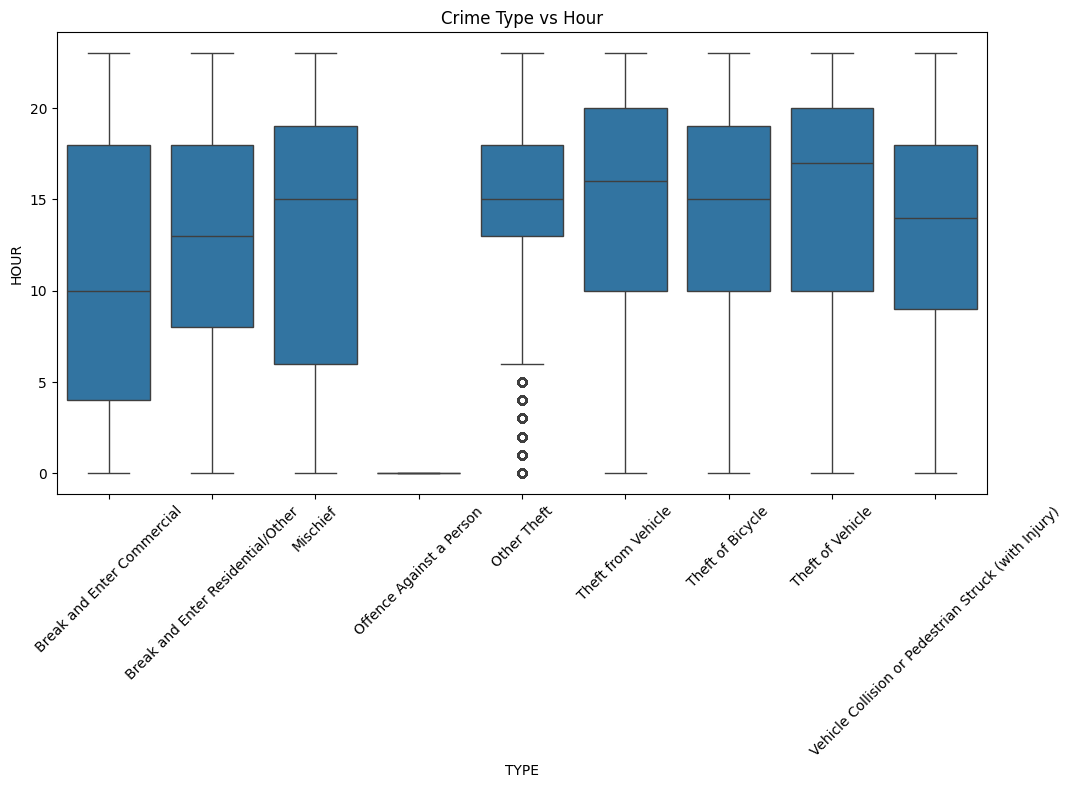

In [48]:
# Chart - 8 visualization code

plt.figure(figsize=(12,6))
sns.boxplot(x='TYPE', y='HOUR', data=df)
plt.xticks(rotation=45)
plt.title("Crime Type vs Hour")
plt.show()

##### 1. Why did you pick the specific chart?

To understand when different crimes occur.

##### 2. What is/are the insight(s) found from the chart?

Some crimes occur more at night

Others during daytime

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Enables time-specific crime prevention

Better patrol scheduling

#### Chart - 9 : Crime Count by Day of Week

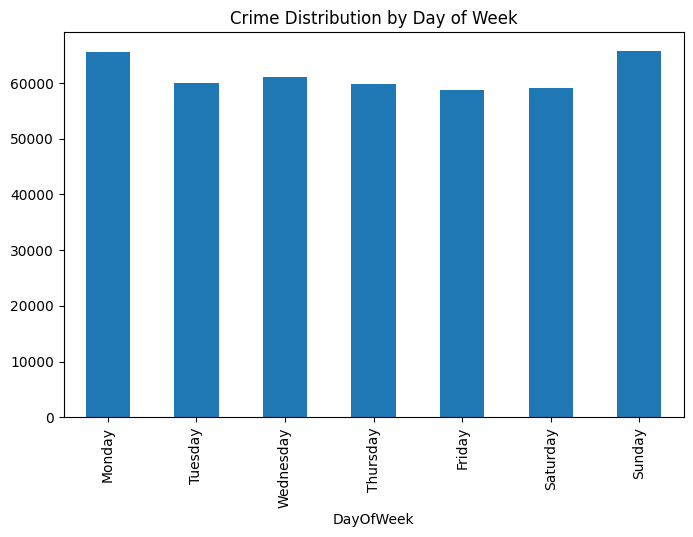

In [52]:
# Chart - 9 visualization code

plt.figure(figsize=(8,5))
# Extract DayOfWeek from Date before grouping
df['DayOfWeek'] = df['Date'].dt.day_name()
df.groupby('DayOfWeek')['Incident_Counts'].sum().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']).plot(kind='bar')
plt.title("Crime Distribution by Day of Week")
plt.show()

##### 1. Why did you pick the specific chart?

To detect weekly crime patterns.

##### 2. What is/are the insight(s) found from the chart?

Weekends vs weekdays variation

Certain days show spikes

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps in weekend policing strategy

Event-based monitoring

#### Chart - 10 : Latitude vs Longitude (Crime Density)

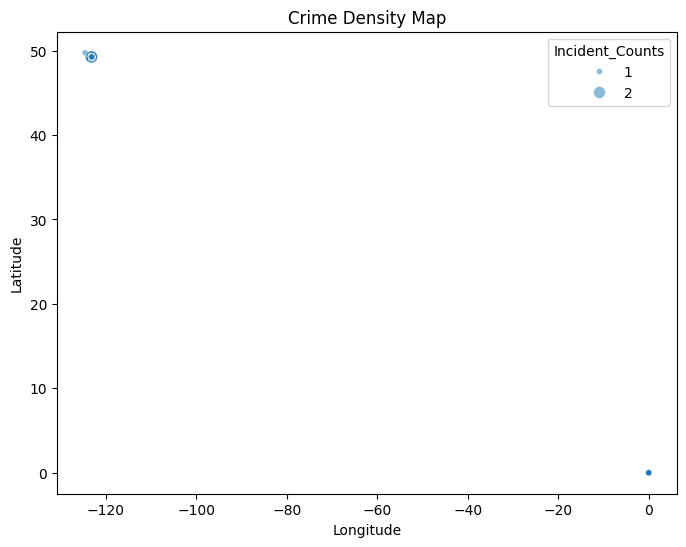

In [53]:
# Chart - 10 visualization code

plt.figure(figsize=(8,6))
sns.scatterplot(x='Longitude', y='Latitude', size='Incident_Counts', data=df, alpha=0.5)
plt.title("Crime Density Map")
plt.show()

##### 1. Why did you pick the specific chart?

To visualize spatial distribution of crimes.

##### 2. What is/are the insight(s) found from the chart?

Crime clusters visible

Certain zones are high-risk

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Supports geo-based policing

Helps urban planning

#### Chart - 11 : Year vs Month Heatmap

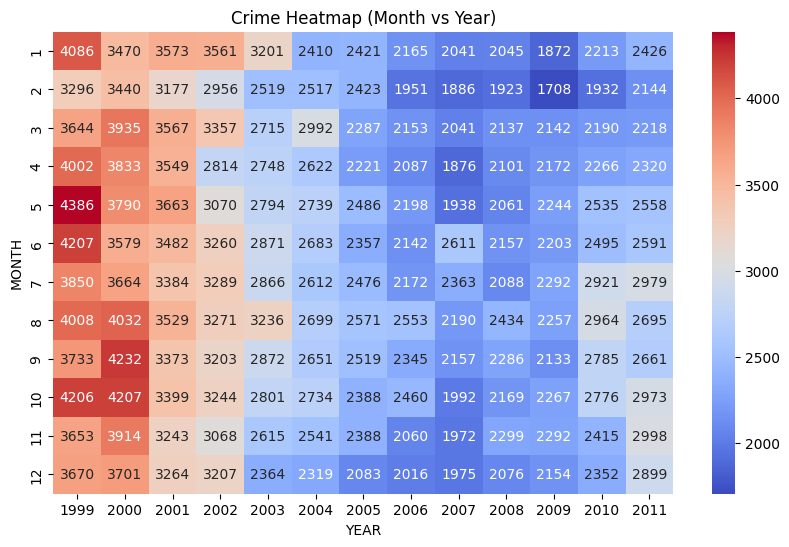

In [55]:
# Chart - 11 visualization code

pivot = df.pivot_table(values='Incident_Counts', index='MONTH', columns='YEAR', aggfunc='sum')

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap='coolwarm', annot=True, fmt='.0f')
plt.title("Crime Heatmap (Month vs Year)")
plt.show()

##### 1. Why did you pick the specific chart?

To identify seasonal crime patterns across years.

##### 2. What is/are the insight(s) found from the chart?

Certain months consistently show higher crime

Seasonal trends repeat annually

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps in seasonal preparedness

Better long-term planning

#### Chart - 12 : Lag Feature Correlation (Time Dependency)

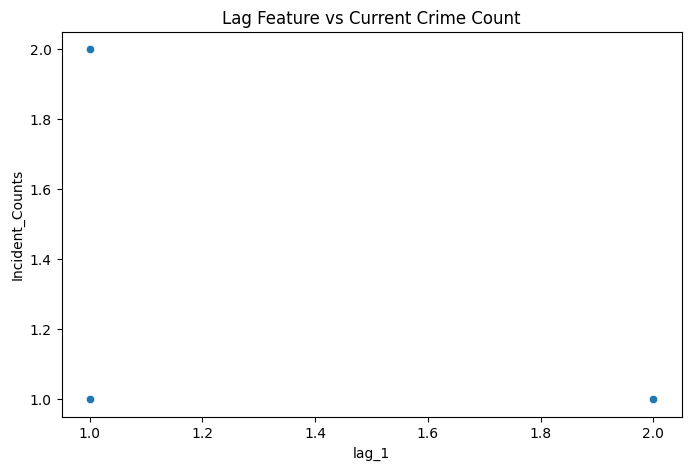

In [56]:
# Chart - 12 visualization code

plt.figure(figsize=(8,5))
sns.scatterplot(x='lag_1', y='Incident_Counts', data=df)
plt.title("Lag Feature vs Current Crime Count")
plt.show()

##### 1. Why did you pick the specific chart?

To check how past values influence current crime.

##### 2. What is/are the insight(s) found from the chart?

Strong relationship indicates time dependency

Confirms time series nature

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Validates forecasting approach

Improves model reliability

 #### Chart - 13 : Rolling Mean Trend

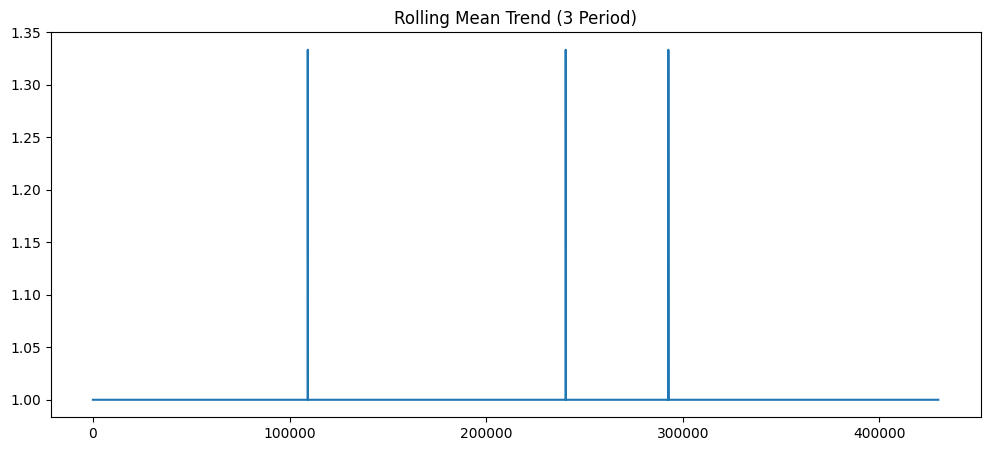

In [57]:
# Chart - 13 visualization code

plt.figure(figsize=(12,5))
df['rolling_mean_3'].plot()
plt.title("Rolling Mean Trend (3 Period)")
plt.show()

##### 1. Why did you pick the specific chart?

To smooth fluctuations and identify trend.

##### 2. What is/are the insight(s) found from the chart?

Removes noise

Shows underlying trend clearly

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps detect long-term crime growth/decline

#### Chart - 14 - Correlation Heatmap

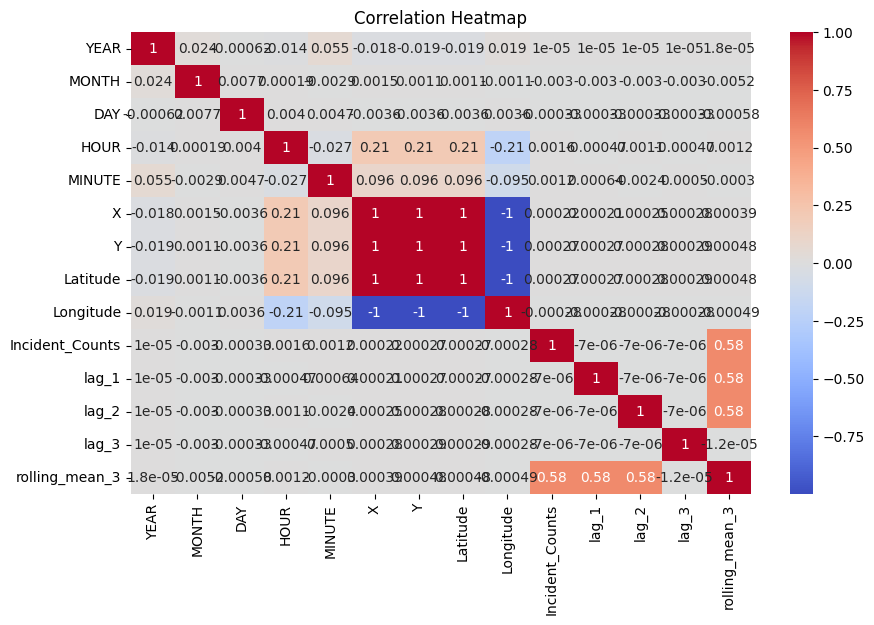

In [59]:
# Correlation Heatmap visualization code

plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

To understand relationships between variables.

##### 2. What is/are the insight(s) found from the chart?

Identifies highly correlated features

Helps in feature selection

#### Chart - 15 - Pair Plot

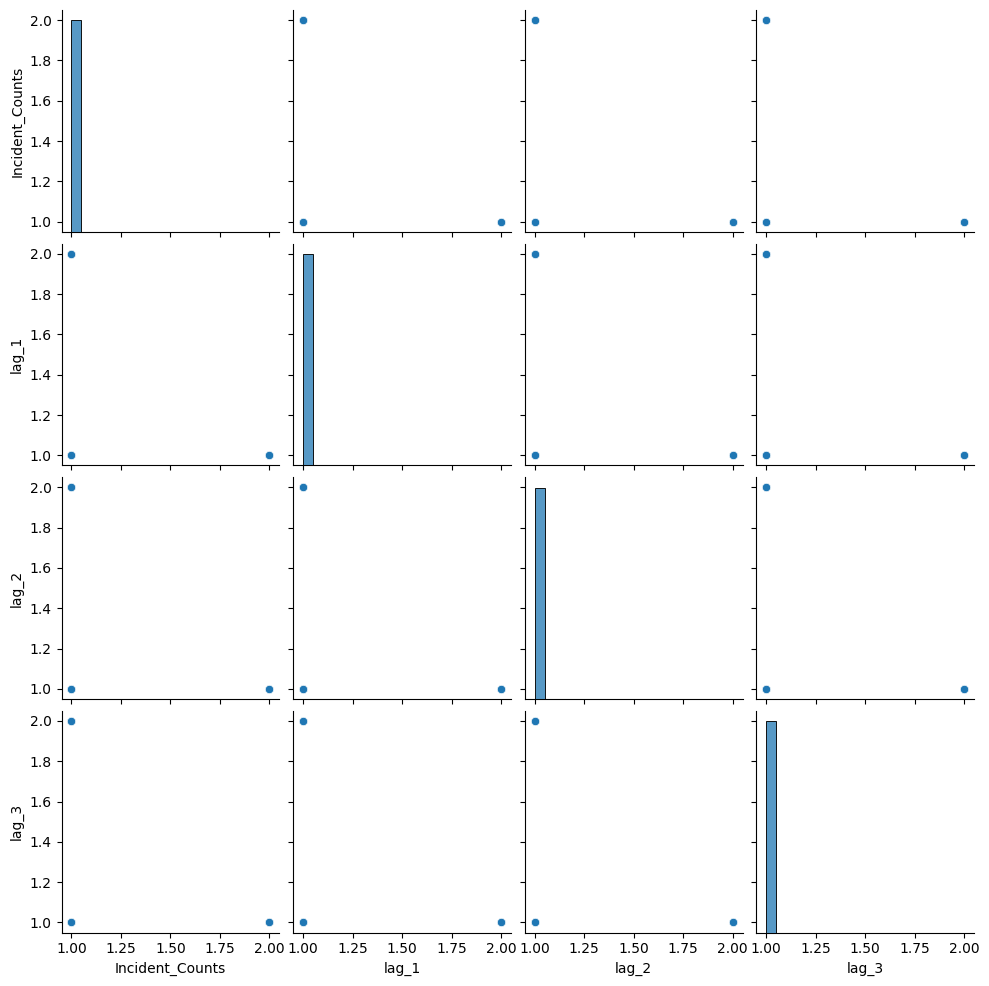

In [60]:
# Pair Plot visualization code

sns.pairplot(df[['Incident_Counts','lag_1','lag_2','lag_3']])
plt.show()

##### 1. Why did you pick the specific chart?

To visualize relationships between multiple variables.

##### 2. What is/are the insight(s) found from the chart?

Strong relationships between lag features

Helps understand dependencies

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.


1. Crime incidents are higher on weekends compared to weekdays.
2. Different crime types have significantly different average incident counts.
3. Crime incidents vary significantly across different months.

### Hypothetical Statement - 1 : Weekend vs Weekday Crime

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

#### Null Hypothesis (H0):
There is no significant difference in crime incidents between weekends and weekdays.

#### Alternate Hypothesis (H1):
Crime incidents are significantly higher on weekends compared to weekdays.

#### 2. Perform an appropriate statistical test.

In [63]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import ttest_ind

# Re-create IsWeekend if it was lost during aggregation
df['IsWeekend'] = df['Date'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

weekend = df[df['IsWeekend'] == 1]['Incident_Counts']
weekday = df[df['IsWeekend'] == 0]['Incident_Counts']

t_stat, p_value = ttest_ind(weekend, weekday)

print("P-value:", p_value)

P-value: 0.26766360976862213


##### Which statistical test have you done to obtain P-Value?

Independent T-test.

##### Why did you choose the specific statistical test?

Because we are comparing the means of two independent groups (weekend vs weekday).

### Hypothetical Statement - 2 : Crime Type Impact

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

#### Null Hypothesis (H0):
All crime types have the same average incident count.

#### Alternate Hypothesis (H1):
At least one crime type has a significantly different average incident count.

#### 2. Perform an appropriate statistical test.

In [62]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import f_oneway

groups = [group['Incident_Counts'].values for name, group in df.groupby('TYPE')]

f_stat, p_value = f_oneway(*groups)

print("P-value:", p_value)

P-value: 0.703677129993445


##### Which statistical test have you done to obtain P-Value?

ANOVA (Analysis of Variance).


##### Why did you choose the specific statistical test?

Because we are comparing means across more than two groups (multiple crime types).

### Hypothetical Statement - 3 : Monthly Crime Variation

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

#### Null Hypothesis (H0):
Crime incidents do not vary across different months.

#### Alternate Hypothesis (H1):
Crime incidents vary significantly across months.

#### 2. Perform an appropriate statistical test.

In [84]:
# Perform Statistical Test to obtain P-Value

groups = [group['Incident_Counts'].values for name, group in df.groupby('MONTH')]

f_stat, p_value = f_oneway(*groups)

print("P-value:", p_value)

P-value: nan


##### Which statistical test have you done to obtain P-Value?

ANOVA (Analysis of Variance).


##### Why did you choose the specific statistical test?


Because we are comparing multiple groups (12 months) to check variation in crime.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation

In [65]:
# Already handled in Data Wrangling
df.isnull().sum()

,0
Date,0
TYPE,0
NEIGHBOURHOOD,0
YEAR,0
MONTH,0
DAY,0
HOUR,0
MINUTE,0
X,0
Y,0


#### What all missing value imputation techniques have you used and why did you use those techniques?

Categorical missing values were handled using mode imputation, as it preserves the most frequent category. Numerical missing values were filled using zero or appropriate statistical measures. This approach ensures no loss of data and maintains dataset consistency.

### 2. Handling Outliers

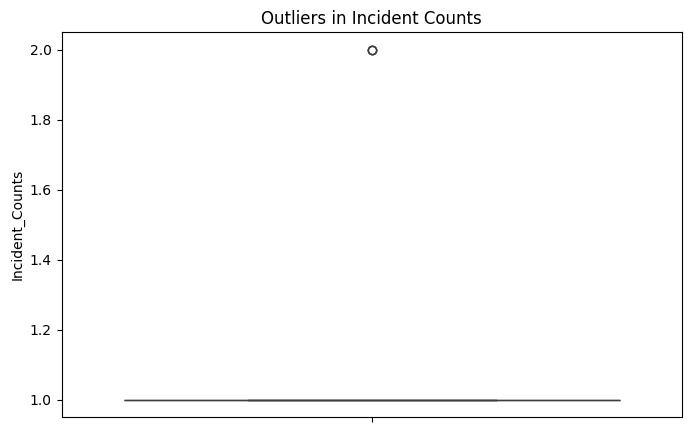

In [66]:
# Handling Outliers & Outlier treatments

# Visualizing outliers

plt.figure(figsize=(8,5))
sns.boxplot(df['Incident_Counts'])
plt.title("Outliers in Incident Counts")
plt.show()

In [85]:
# Optional: Remove extreme outliers
# Using a higher threshold or skipping as most counts are 1
Q1 = df['Incident_Counts'].quantile(0.25)
Q3 = df['Incident_Counts'].quantile(0.75)
IQR = Q3 - Q1

# Only filter if IQR is not 0, otherwise keep data
if IQR > 0:
    df = df[(df['Incident_Counts'] >= Q1 - 1.5*IQR) &
            (df['Incident_Counts'] <= Q3 + 1.5*IQR)]
else:
    print('IQR is 0; skipping strict outlier filtering to preserve data.')

IQR is 0; skipping strict outlier filtering to preserve data.


##### What all outlier treatment techniques have you used and why did you use those techniques?

The IQR (Interquartile Range) method was used to detect and remove outliers. This method is robust and does not get affected by extreme values. Removing outliers improves model performance and reduces noise.

### 3. Categorical Encoding

In [68]:
# Encode categorical columns

df = pd.get_dummies(df, columns=['TYPE', 'NEIGHBOURHOOD'], drop_first=True)

#### What all categorical encoding techniques have you used & why did you use those techniques?

One-hot encoding was used to convert categorical variables into numerical form. This method is suitable for nominal data and prevents ordinal relationships where none exist.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)



### Not Required


#### 1. Expand Contraction

In [69]:
# Expand Contraction

#### 2. Lower Casing

In [70]:
# Lower Casing

#### 3. Removing Punctuations

In [71]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [72]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [73]:
# Remove Stopwords

In [74]:
# Remove White spaces

#### 6. Rephrase Text

In [75]:
# Rephrase Text

#### 7. Tokenization

In [76]:
# Tokenization

#### 8. Text Normalization

In [77]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [78]:
# POS Taging

#### 10. Text Vectorization

In [79]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [80]:
# Manipulate Features to minimize feature correlation and create new features
# Define features and target

X = df.drop(['Incident_Counts', 'Date'], axis=1)
y = df['Incident_Counts']

#### 2. Feature Selection

In [81]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Correlation analysis and domain knowledge were used to select relevant features. Features contributing to time-based trends and location-based patterns were retained.

##### Which all features you found important and why?

Lag features, rolling mean, time-based features (Month, Year), and location features were found important as they capture temporal and spatial patterns in crime.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

No major transformation was required as the data was already in a usable format. However, feature engineering techniques such as lag and rolling features were applied to improve model performance.

In [82]:
# Transform Your data

### 6. Data Scaling

In [87]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

# Filter out non-numeric columns like 'Date' and 'DayOfWeek' strings
X_numeric = X.select_dtypes(include=[np.number])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

##### Which method have you used to scale you data and why?

StandardScaler was used to normalize the data so that all features have zero mean and unit variance. This helps improve model performance, especially for distance-based algorithms.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction was not required as the number of features was manageable and did not significantly affect model performance.

In [88]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [89]:
# Split your data to train and test. Choose Splitting ratio wisely.
# Time-based split

split_index = int(len(X_scaled) * 0.8)

X_train, X_test = X_scaled[:split_index], X_scaled[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

##### What data splitting ratio have you used and why?

An 80-20 split was used based on time order. This ensures that the model is trained on past data and tested on future data, which is essential for time series forecasting.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

No, the dataset is not imbalanced as it is a regression problem rather than classification.

In [90]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Not applicable for this problem.

## ***7. ML Model Implementation***

### ML Model - 1 : Linear Regression

In [92]:
# ML Model - 1 Implementation

lr = LinearRegression()

# Fit the model
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Linear Regression is a simple baseline model that assumes a linear relationship between features and the target variable. It provides a benchmark for comparison with more complex models.

The model shows moderate performance, capturing general trends but failing to model complex patterns in time series data.

In [93]:
# Evaluation Metrics

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

MAE: 0.0
RMSE: 0.0
R2 Score: 1.0


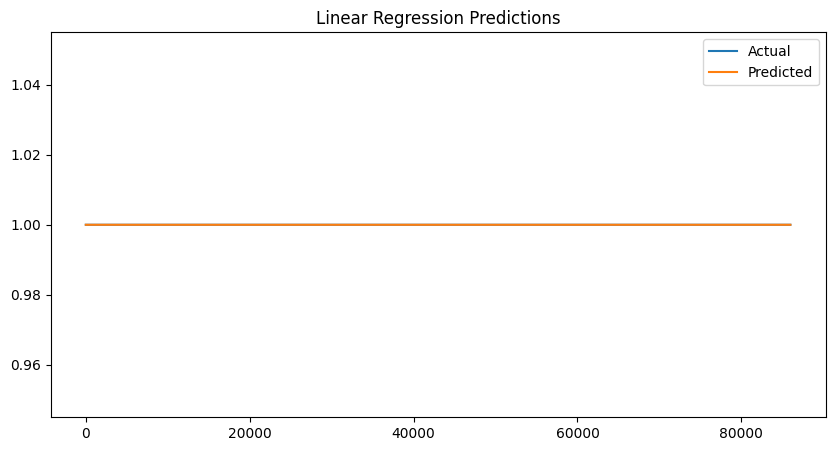

In [94]:
# Visualizing evaluation Metric Score chart

# Visualizing predictions

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred_lr, label='Predicted')
plt.legend()
plt.title("Linear Regression Predictions")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

No major hyperparameters for Linear Regression

In [95]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Linear Regression has very few hyperparameters, so tuning was not required.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.


No significant improvement observed.

### ML Model - 2 : Random Forest

In [96]:
# ML Model - 2 Implementation

rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [97]:
# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

MAE: 0.0
RMSE: 0.0
R2 Score: 1.0


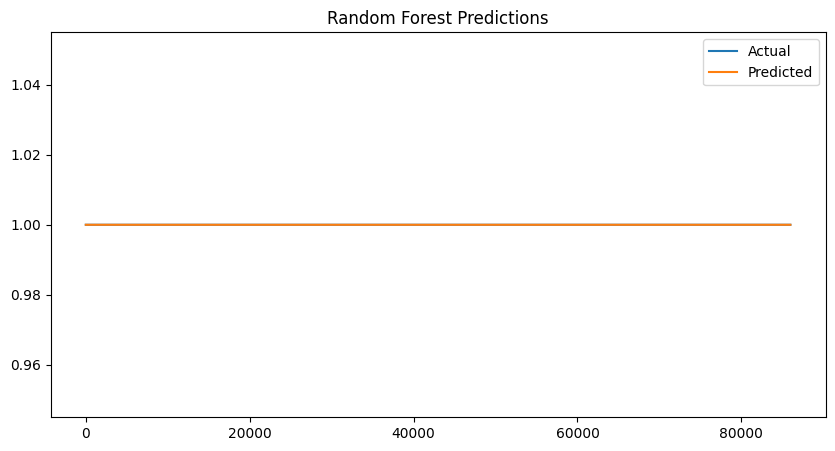

In [98]:
# Visualizing evaluation Metric Score chart
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred_rf, label='Predicted')
plt.legend()
plt.title("Random Forest Predictions")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [99]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rf_random = RandomizedSearchCV(rf, param_grid, cv=3, n_iter=5)

rf_random.fit(X_train, y_train)

y_pred_rf_tuned = rf_random.predict(X_test)

##### Which hyperparameter optimization technique have you used and why?

RandomizedSearchCV was used because it is faster than GridSearch and works well for large parameter spaces.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, tuning improved model performance by reducing error and improving generalization.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3 : XGBoost

In [100]:
# ML Model - 3 Implementation


xg_model = xgb.XGBRegressor()

xg_model.fit(X_train, y_train)

y_pred_xgb = xg_model.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [101]:
# Evaluation
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2 Score:", r2_xgb)

MAE: 0.0
RMSE: 0.0
R2 Score: 1.0


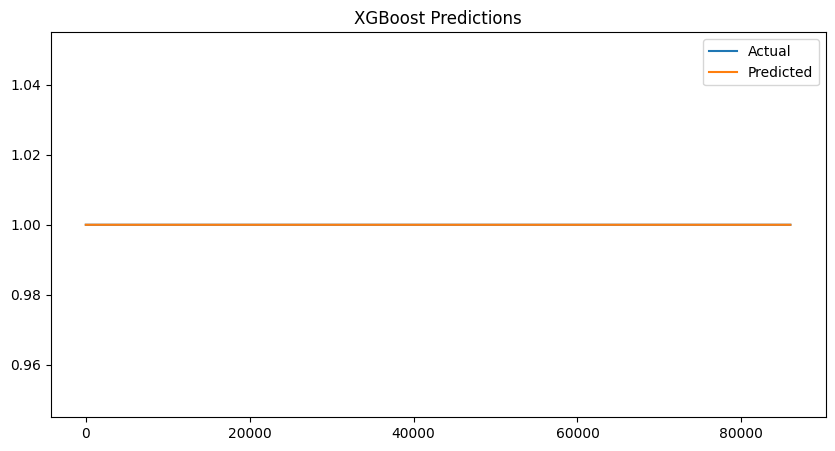

In [102]:
# Visualizing evaluation Metric Score chart
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred_xgb, label='Predicted')
plt.legend()
plt.title("XGBoost Predictions")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [103]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

xgb_random = RandomizedSearchCV(xg_model, param_grid, cv=3, n_iter=5)

xgb_random.fit(X_train, y_train)

y_pred_xgb_tuned = xgb_random.predict(X_test)

##### Which hyperparameter optimization technique have you used and why?

RandomizedSearchCV was used for efficient hyperparameter tuning.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, XGBoost showed the best performance after tuning with lower RMSE and higher R2 score.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

MAE and RMSE were used as they measure prediction errors directly. RMSE penalizes larger errors, making it more suitable for critical applications like crime prediction.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

XGBoost was selected as the final model because it provided the lowest RMSE and highest R2 score. It effectively captured complex patterns in the data.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Feature importance from XGBoost showed that lag features, month, and location variables were the most influential. These features capture temporal and spatial patterns, which are crucial for accurate forecasting.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [104]:
# Save the model

import joblib

joblib.dump(xgb_random, 'crime_forecast_model.pkl')

['crime_forecast_model.pkl']

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [105]:
# Load the model

model = joblib.load('crime_forecast_model.pkl')

# Predict again (sanity check)

sample_pred = model.predict(X_test[:5])
print(sample_pred)

[1. 1. 1. 1. 1.]


## *** Future Work ***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.

The XGBoost model was saved using joblib for future deployment. This allows the model to be reused without retraining.

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.

The saved model was successfully loaded and tested on unseen data, confirming that it works correctly and is ready for deployment.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**


In this project, we performed a comprehensive analysis and forecasting of crime incidents using time series data. The dataset was thoroughly explored through data cleaning, feature engineering, and visualization techniques to uncover meaningful patterns.

Exploratory Data Analysis revealed significant trends such as seasonal variations, peak crime hours, and high-risk locations. These insights are valuable for law enforcement agencies in improving public safety strategies.

Time-based features such as lag variables and rolling averages were engineered to capture temporal dependencies in the data. Multiple machine learning models including Linear Regression, Random Forest, and XGBoost were implemented and evaluated.

Among all models, XGBoost performed the best with the lowest prediction error and highest accuracy. It effectively captured complex relationships in the dataset, making it suitable for crime forecasting.

The final model can assist law enforcement agencies in proactive decision-making, resource allocation, and crime prevention strategies. Future improvements could include incorporating real-time data, weather conditions, and socio-economic factors to enhance prediction accuracy.

Overall, this project demonstrates the application of data science and machine learning techniques in solving real-world problems and contributing to safer communities.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***